# OBB wing detector: predictions of the best pilot model

`models/obb/best-dota.pt` is the best checkpoint of the pilot run `pilot-dota` (start: Ultralytics YOLO26n-OBB trained on DOTA, 40 epochs, `configs/obb/pilot-dota.yaml`).
Below: random samples of the frozen validation set (single wings and compositions of 2-4 wings, with random rotation, debris and brightness).
The **prediction is green** with its confidence; the **ground truth is red** and drawn underneath, so a red fringe around the green line means a deviation.
The title gives the IoU of every ground-truth box with its best prediction (and the number of extra boxes, if any).

The frozen test set is for the final model only (`SPLIT = "test"` would switch to it).

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

from wings.config import MODELS_DIR
from wings.detection.obb_dataset import DEFAULT_OUT_DIR

WEIGHTS = MODELS_DIR / "obb" / "best-dota.pt"
SPLIT = "test"  # the frozen test set is for the final model only
N_SINGLE, N_MULTI = 8, 4  # single wings and compositions to show
CONF = 0.25
SEED = 0  # change it to see other samples

model = YOLO(str(WEIGHTS))
device = 0 if torch.cuda.is_available() else "cpu"
images_dir = DEFAULT_OUT_DIR / SPLIT / "images"
labels_dir = DEFAULT_OUT_DIR / SPLIT / "labels"


def ground_truth(path):
    """Ground-truth corners (n, 4, 2) in pixels of a frozen sample (the label file stores them normalised)."""
    size = cv2.imread(str(path)).shape[0]
    lines = (labels_dir / f"{path.stem}.txt").read_text().splitlines()
    return np.array([np.array(line.split()[1:], dtype=np.float32) for line in lines if line.strip()]).reshape(-1, 4, 2) * size


def iou(a, b):
    """IoU of two oriented boxes (convex polygons)."""
    a, b = a.astype(np.float32), b.astype(np.float32)
    inter, _ = cv2.intersectConvexConvex(a, b)
    return inter / (cv2.contourArea(a) + cv2.contourArea(b) - inter)


def draw(ax, polygons, **style):
    for polygon in polygons:
        ax.plot(*np.vstack([polygon, polygon[:1]]).T, **style)

2026-10-09 16:05:36.418 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-10-09 16:05:38.235 | INFO     | wings.config:<module>:66 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


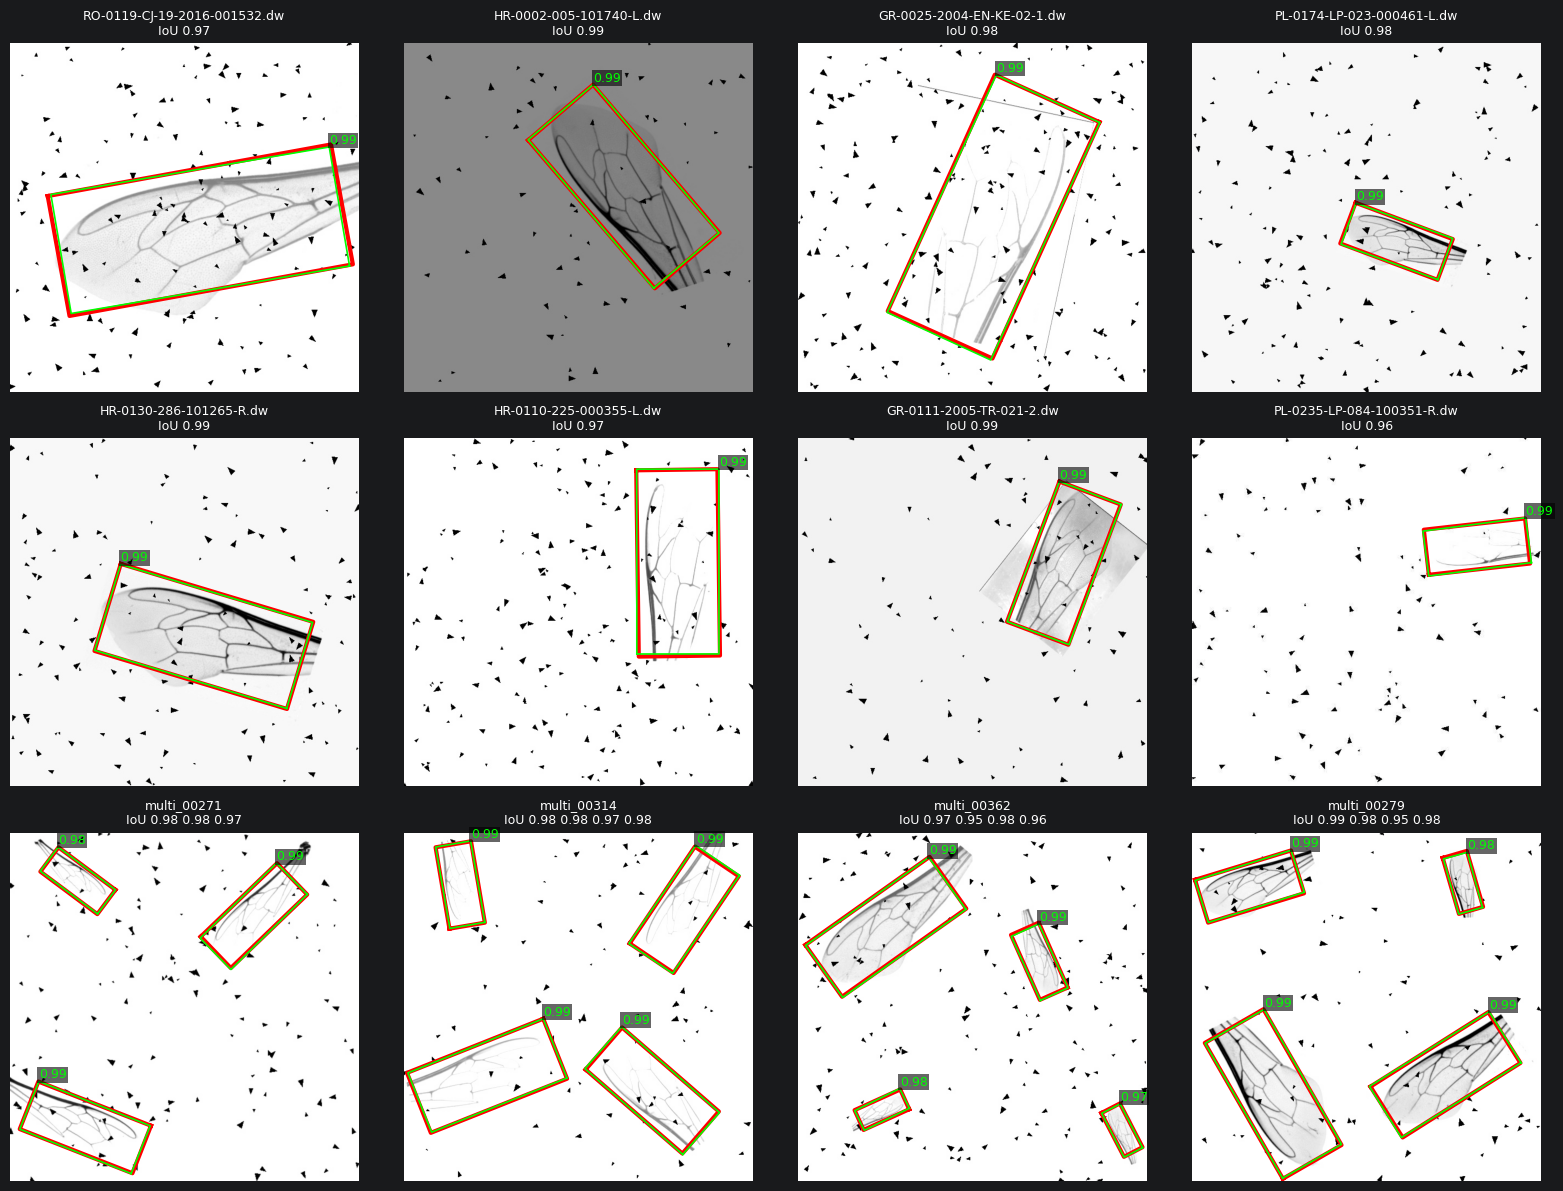

In [2]:
rng = np.random.default_rng(SEED)
files = sorted(images_dir.glob("*.jpg"))
singles = [f for f in files if not f.name.startswith("multi_")]
multis = [f for f in files if f.name.startswith("multi_")]
picked = [singles[i] for i in rng.choice(len(singles), N_SINGLE, replace=False)] + [multis[i] for i in rng.choice(len(multis), N_MULTI, replace=False)]

results = model.predict([str(p) for p in picked], imgsz=640, conf=CONF, device=device, verbose=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, path, result in zip(axes.flat, picked, results):
    boxes, scores = result.obb.xyxyxyxy.cpu().numpy(), result.obb.conf.cpu().numpy()
    truth = ground_truth(path)
    ax.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
    draw(ax, truth, color="red", lw=3)
    draw(ax, boxes, color="lime", lw=1.2)
    for box, score in zip(boxes, scores):
        ax.text(*box[box[:, 1].argmin()], f"{score:.2f}", color="lime", fontsize=9, va="bottom", bbox=dict(facecolor="black", alpha=0.6, pad=1, edgecolor="none"))
    ious = [max((iou(t, b) for b in boxes), default=0.0) for t in truth]
    extra = len(boxes) - len(truth)
    ax.set_title(f"{path.stem}\nIoU " + " ".join(f"{v:.2f}" for v in ious) + (f"  (+{extra} extra)" if extra > 0 else ""), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()